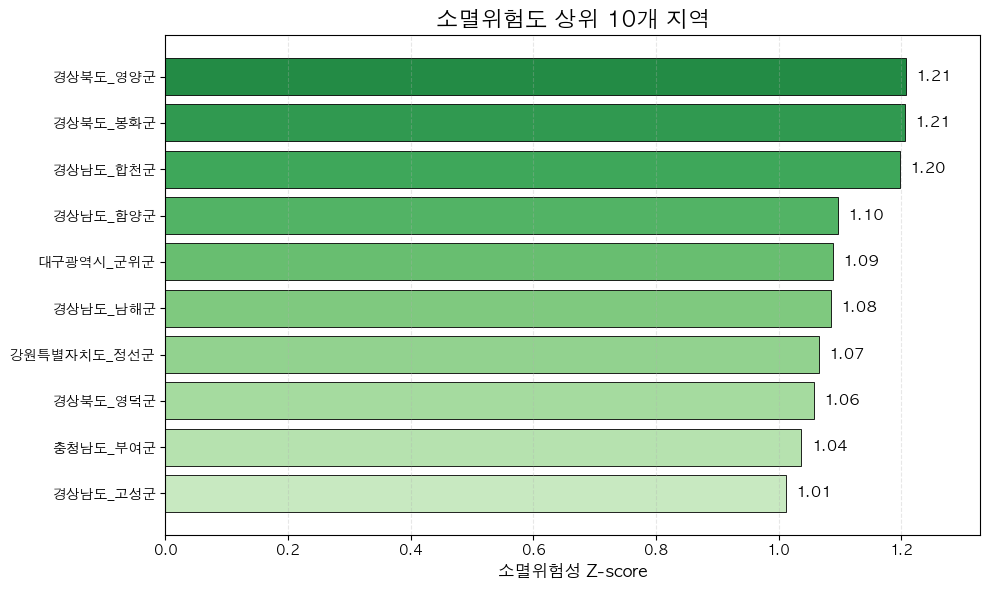

In [18]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

plt.rcParams['font.family'] = 'AppleGothic'
plt.rcParams['axes.unicode_minus'] = False

df = pd.read_excel("data/lastRank.xlsx")

top10 = df.sort_values("소멸위험성_zscore", ascending=False).head(10)

colors = plt.cm.Greens_r(np.linspace(0.25, 0.75, len(top10)))

plt.figure(figsize=(10,6))

bars = plt.barh(
    top10["지역명"],
    top10["소멸위험성_zscore"],
    color=colors,
    edgecolor="black",
    linewidth=0.6
)

plt.gca().invert_yaxis()

plt.xlabel("소멸위험성 Z-score", fontsize=12)
plt.title("소멸위험도 상위 10개 지역", fontsize=16, fontweight="bold")

plt.xlim(0, top10["소멸위험성_zscore"].max() + 0.12)

for bar in bars:
    width = bar.get_width()
    plt.text(
        width + 0.015,
        bar.get_y() + bar.get_height()/2,
        f"{width:.2f}",
        va='center',
        ha='left',
        fontsize=11,
        fontweight='bold'
    )

plt.grid(axis="x", linestyle="--", alpha=0.3)

plt.tight_layout()
plt.show()

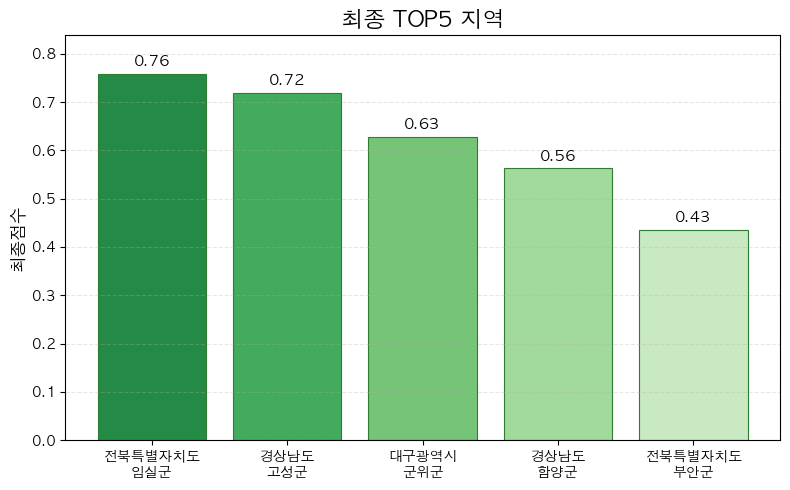

In [25]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

plt.rcParams['font.family'] = 'AppleGothic'      
plt.rcParams['axes.unicode_minus'] = False

df = pd.read_excel("data/lastRank.xlsx")

top5 = df.sort_values("최종순위").head(5)
top5["지역명"] = top5["지역명"].str.replace("_", "\n")

colors = plt.cm.Greens_r(np.linspace(0.25, 0.75, 5))

plt.figure(figsize=(8, 5))

bars = plt.bar(
    top5["지역명"],
    top5["최종점수"],
    color=colors,
    edgecolor="#2E7D32",
    linewidth=0.8
)

plt.title("최종 TOP5 지역", fontsize=16, fontweight="bold")
plt.ylabel("최종점수", fontsize=12)

plt.ylim(0, top5["최종점수"].max() + 0.08)

for bar in bars:
    h = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        h + 0.01,
        f"{h:.2f}",
        ha="center",
        va="bottom",
        fontsize=11,
        fontweight="bold"
    )


plt.grid(axis="y", linestyle="--", alpha=0.3)

plt.tight_layout()
plt.show()

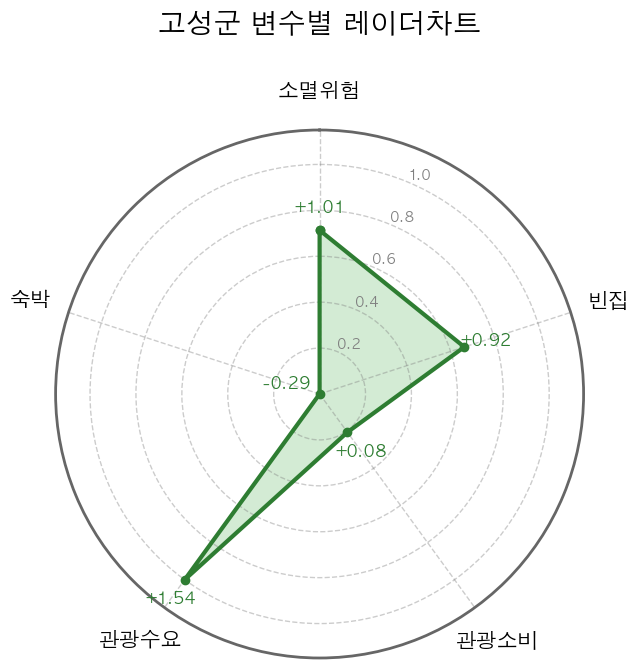

In [47]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

plt.rcParams["font.family"] = "AppleGothic"
plt.rcParams["axes.unicode_minus"] = False

df = pd.read_excel("data/lastRank.xlsx")

row = df[df["지역명"] == "경상남도_고성군"].iloc[0]

labels = [
    "소멸위험",
    "빈집",
    "관광소비",
    "관광수요",
    "숙박"
]

real_values = np.array([
    row["소멸위험성_zscore"],
    row["빈집_zscore"],
    row["관광소비_zscore"],
    row["관광수요_zscore"],
    row["숙박공급압박_zscore"]
])

values = (real_values - real_values.min()) / (real_values.max() - real_values.min())

angles = np.linspace(0, 2*np.pi, len(labels), endpoint=False)

angles = np.concatenate([angles, [angles[0]]])
values = np.concatenate([values, [values[0]]])

fig = plt.figure(figsize=(8, 8))
ax = fig.add_axes([0.17, 0.23, 0.66, 0.66], polar=True)

ax.set_theta_offset(np.pi / 2)
ax.set_theta_direction(-1)

ax.plot(
    angles,
    values,
    color="#2E7D32",
    linewidth=3,
    marker="o",
    markersize=6
)

ax.fill(
    angles,
    values,
    color="#81C784",
    alpha=0.35
)

ax.set_xticks(angles[:-1])

ax.set_xticklabels(
    labels,
    fontsize=15,
    fontweight="bold"
)

ax.tick_params(axis="x", pad=18)

ax.set_ylim(0, 1.15)

ax.set_yticks([0.2, 0.4, 0.6, 0.8, 1.0])

ax.set_yticklabels(
    ["0.2", "0.4", "0.6", "0.8", "1.0"],
    fontsize=10,
    color="gray"
)

for angle, value, score in zip(angles[:-1], values[:-1], real_values):

    r = value + 0.10 if score >= 0 else value + 0.15

    ax.text(
        angle,
        r,
        f"{score:+.2f}",
        fontsize=12,
        fontweight="bold",
        color="#2E7D32",
        ha="center",
        va="center"
    )

ax.grid(
    linestyle="--",
    linewidth=1,
    alpha=0.4,
    color="gray"
)

ax.spines["polar"].set_linewidth(2)
ax.spines["polar"].set_color("#666666")

plt.title(
    "고성군 변수별 레이더차트",
    fontsize=20,
    fontweight="bold",
    pad=35
)

plt.show()

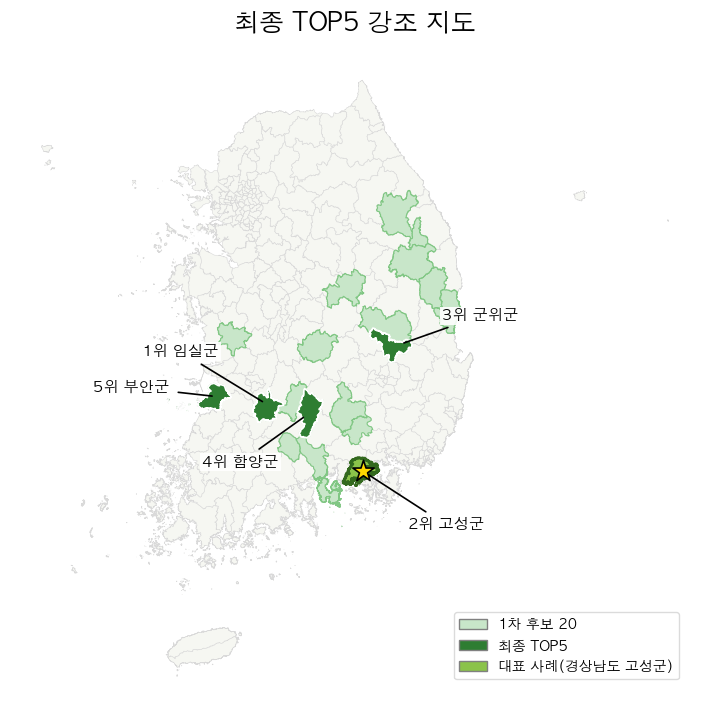

In [71]:
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

plt.rcParams["font.family"] = "AppleGothic"
plt.rcParams["axes.unicode_minus"] = False

df = pd.read_excel("data/lastRank.xlsx")
gdf = gpd.read_file("data/bnd_sigungu_00_2025_2Q.shp")

df["시군구"] = df["지역명"].str.split("_").str[-1]

gdf = gdf.merge(
    df,
    left_on="SIGUNGU_NM",
    right_on="시군구",
    how="left"
)

# 강원 고성군 제거 (32600), 경남 고성군 유지 (38540)
gdf.loc[
    gdf["SIGUNGU_CD"] == "32600",
    ["지역명","최종점수","최종순위",
     "소멸위험성_zscore","관광수요_zscore",
     "관광소비_zscore","빈집_zscore","숙박공급압박_zscore"]
] = np.nan

top20 = gdf[gdf["최종순위"] <= 20]
top5 = gdf[gdf["최종순위"] <= 5]
gosung = gdf[gdf["SIGUNGU_CD"] == "38540"]

fig, ax = plt.subplots(figsize=(7.2,9))

gdf.plot(ax=ax,color="#F6F7F2",edgecolor="#D9D9D9",linewidth=0.4)
top20.plot(ax=ax,color="#C8E6C9",edgecolor="#81C784",linewidth=0.8)
top5.plot(ax=ax,color="#2E7D32",edgecolor="white",linewidth=1.2)
gosung.plot(ax=ax,color="#8BC34A",edgecolor="#33691E",linewidth=2)

offsets = {
    "임실군": (-90000, 55000),
    "고성군": (85000, -55000),
    "군위군": (85000, 30000),
    "함양군": (-70000, -50000),
    "부안군": (-90000, 10000),
}

for _, row in top5.iterrows():
    p = row.geometry.representative_point()
    dx, dy = offsets.get(row["SIGUNGU_NM"], (50000,50000))
    ax.annotate(
        f"{int(row['최종순위'])}위 {row['SIGUNGU_NM']}",
        xy=(p.x,p.y),
        xytext=(p.x+dx,p.y+dy),
        fontsize=11,
        fontweight="bold",
        ha="center",
        va="center",
        bbox=dict(facecolor="white",edgecolor="none",alpha=0.9,pad=1.5),
        arrowprops=dict(
            arrowstyle="-",
            color="black",
            lw=1.2,
            shrinkA=5,
            shrinkB=5
        ),
        zorder=20
    )

p = gosung.geometry.representative_point().iloc[0]
ax.scatter(
    p.x,p.y,
    marker="*",
    s=260,
    color="gold",
    edgecolors="black",
    linewidth=1.2,
    zorder=30
)

legend = [
    Patch(facecolor="#C8E6C9",edgecolor="gray",label="1차 후보 20"),
    Patch(facecolor="#2E7D32",edgecolor="gray",label="최종 TOP5"),
    Patch(facecolor="#8BC34A",edgecolor="gray",label="대표 사례(경상남도 고성군)")
]

ax.legend(
    handles=legend,
    loc="lower right",
    bbox_to_anchor=(0.98, 0.03),
    fontsize=10,
    frameon=True,
    facecolor="white",
    edgecolor="lightgray"
)

ax.set_title("최종 TOP5 강조 지도",fontsize=18,fontweight="bold",pad=15)
ax.set_axis_off()
plt.tight_layout()
plt.show()
